# Datos Faltantes

In [1]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.impute import SimpleImputer, KNNImputer
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Cargar el conjunto de datos
diabetes = load_diabetes(as_frame=True)
data = diabetes.data
data['target'] = diabetes.target

In [7]:
data.sample(100)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
346,0.005383,0.050680,0.017506,0.032201,0.127771,0.127390,-0.021311,0.071210,0.062578,0.015491,139.0
385,0.023546,0.050680,-0.019140,0.049415,-0.063487,-0.061125,0.004460,-0.039493,-0.025953,-0.013504,219.0
300,0.016281,-0.044642,0.073552,NaN,-0.004321,-0.013527,-0.013948,-0.001116,0.042897,0.044485,275.0
249,-0.012780,-0.044642,0.060618,0.052858,0.047965,0.029375,-0.017629,0.034309,0.070207,0.007207,215.0
...,...,...,...,...,...,...,...,...,...,...,...
233,0.067136,-0.044642,0.036907,-0.050427,-0.023584,-0.034508,0.048640,-0.039493,-0.025953,-0.038357,90.0
15,-0.052738,0.050680,-0.018062,0.080401,0.089244,0.107662,-0.039719,0.108111,0.036060,-0.042499,171.0
247,-0.081798,-0.044642,-0.081653,-0.040099,0.002559,-0.018537,0.070730,-0.039493,-0.010903,-0.092204,51.0
427,-0.034575,0.050680,NaN,-0.005670,-0.073119,-0.062691,-0.006584,-0.039493,-0.045424,0.032059,67.0


In [9]:
# Simular valores faltantes
np.random.seed(42)
data.loc[data.sample(frac=0.1).index, 'bmi'] = np.nan
data.loc[data.sample(frac=0.1).index, 'bp'] = np.nan

# Ejercicios
Contesta las siguientes preguntas. Para cada pregunta, deberás escribir código que demostrará cómo llegaste al resultado:

### 1. ¿Cuántos valores faltantes hay en cada columna?**

In [10]:
# Contar valores faltantes por columna
missing_values = data.isnull().sum()

print("Valores faltantes por columna:")
print(missing_values)

Valores faltantes por columna:
age        0
sex        0
bmi       44
bp        44
s1         0
s2         0
s3         0
s4         0
s5         0
s6         0
target     0
dtype: int64


Con el bloque de codigo anterior identifique valores faltantes en las columans 'bmi' y 'bp', las cuales fueron modificadas intencionalmente para simular datos incompletos. El resto de las columnas no presentan valores faltantes, tambien se modifico el bloque de "data.sample(10)" por "data.sample(100)" con la intecion de mostrar algunos valores "NaN" de forma visual en las columnas.

### 2. Utiliza imputación simple (media) para llenar los valores faltantes de la columna 'bmi'.

In [11]:
# Crear imputador usando la media
simple_imputer = SimpleImputer(strategy='mean')

# Imputar columna bmi
data['bmi_imputed'] = simple_imputer.fit_transform(data[['bmi']])

# Mostrar algunas filas
print(data[['bmi', 'bmi_imputed']].head(10))

        bmi  bmi_imputed
0  0.061696     0.061696
1 -0.051474    -0.051474
2  0.044451     0.044451
3 -0.011595    -0.011595
4 -0.036385    -0.036385
5 -0.040696    -0.040696
6 -0.047163    -0.047163
7 -0.001895    -0.001895
8  0.061696     0.061696
9       NaN    -0.000205


Se realizó la imputacion simple usando la media. En el resultado se imprimieron las columnas bmi (columna original) y bmi_imputed(conlumna con la imputacion aplicada), con el fin de mostrar el cambio y que funcionó correctamente.

### 3. Utiliza KNNImputer para imputar valores en las columnas 'bmi' y 'bp'. Compara los resultados con los de la imputación simple.

In [12]:
# Crear imputador KNN
knn_imputer = KNNImputer(n_neighbors=3)

# Aplicar imputación KNN
knn_imputed = knn_imputer.fit_transform(data[['bmi', 'bp']])

# Convertir a DataFrame
knn_df = pd.DataFrame(knn_imputed, columns=['bmi_knn', 'bp_knn'])

# Combinar resultados
comparison = pd.concat([
    data[['bmi', 'bp', 'bmi_imputed']],
    knn_df
], axis=1)

# Mostrar resultados
print(comparison.head(10))

        bmi        bp  bmi_imputed   bmi_knn    bp_knn
0  0.061696  0.021872     0.061696  0.061696  0.021872
1 -0.051474       NaN    -0.051474 -0.051474  0.024168
2  0.044451 -0.005670     0.044451  0.044451 -0.005670
3 -0.011595 -0.036656    -0.011595 -0.011595 -0.036656
4 -0.036385  0.021872    -0.036385 -0.036385  0.021872
5 -0.040696 -0.019442    -0.040696 -0.040696 -0.019442
6 -0.047163 -0.015999    -0.047163 -0.047163 -0.015999
7 -0.001895  0.066629    -0.001895 -0.001895  0.066629
8  0.061696 -0.040099     0.061696  0.061696 -0.040099
9       NaN -0.033213    -0.000205 -0.018780 -0.033213


Aquí se puede observar que la imputación simple reemplaza todos los valores faltantes utilizando la misma media calculada para la columna, mientras que KNNImputer estima valores diferentes para cada fila tomando base en observaciones similares del conjunto de datos.

### 4. Genera un histograma comparando los datos antes y después de la imputación en la columna 'bmi'.

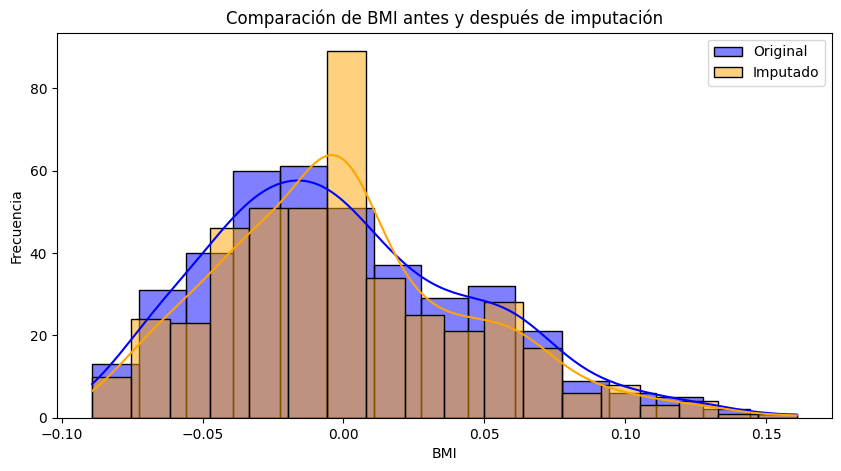

In [13]:
# Crear figura
plt.figure(figsize=(10,5))

# Histograma original
sns.histplot(data['bmi'], color='blue', label='Original', kde=True)

# Histograma imputado
sns.histplot(data['bmi_imputed'], color='orange', label='Imputado', kde=True)

# Títulos
plt.title('Comparación de BMI antes y después de imputación')
plt.xlabel('BMI')
plt.ylabel('Frecuencia')

# Leyenda
plt.legend()

# Mostrar gráfica
plt.show()